## Notebook Description: Analysis of Forage Accessions for Gas Production and Methane Emissions

This notebook performs a comprehensive analysis of gas production and methane emissions data from various forage accessions across different experimental subsets. It begins with data loading, followed by extensive cleaning and preprocessing steps, including handling missing values, standardizing accession identifiers (e.g., `id_lab`, `id`), and unifying `functional_group` categories. The core methodology involves calculating mean values for key numeric metrics such as $\text{net_gas_8h_ml}$, $\text{ch4_percentage_in_gas_24h}$, $\text{methane_intensity}$, and $\text{tddm}$ for each unique accession. Subsequently, descriptive statistics are generated for combined subsets (1&2, 3, and all data) to summarize the data distribution. The notebook also employs box plots to visually compare the distributions of crucial variables like $\text{CH}_4 \text{ percentage in gas at 8h}$, $\text{CH}_4 \text{ percentage in gas at 24h}$, $\text{Methane Intensity}$, and $\text{TDDM}$ across the different subsets, saving these visualizations for further reference. Finally, the processed and aggregated data is prepared and filtered for potential use in a dashboard, providing a clear overview of the performance of various forage types.

# Connecting colab to Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


# Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Data import

In [ ]:
ciat_gas = pd.read_csv('/content/drive/MyDrive/lmf/data/03_25_2026/ciat_gas_subsets_123.csv', encoding='latin-1') # Subsets 1, 2 and 3
ciat_gas.head()

,no,center,id_lab,id,run,replication,genus,species,tax_name,family,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml/g_dm_incubated_24h,tddm,ch4_ml/g_NDF_digested_24h,methane_intensity,subset
0,No,CENTER,Internal ID lab (when possible),Gene bank /Breeding program ID,Run,Replication,Genus,Species,Tax Name,Family,...,"Net gas 24h, ml","CH4 8h, ml","CH4 24h, ml","CH4 % in gas, h8","CH4 % in gas, 24h","Gas ml/g DM Incubated, 24h","% DMD, Truly digestibility",CH4 ml/g NDF digested in 24 h,"CH4 ml/g DMD, 24h",NaN
1,1,CIAT,Blank,Blank,1,1,Blank,Blank,Blank,Blank,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,2,CIAT,Blank,Blank,1,2,Blank,Blank,Blank,Blank,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,3,CIAT,F24 3416,ABC-705-1,1,1,Indigofera,suffruticosa,Indigofera suffruticosa,Fabaceae,...,62.58,4.00,11.16,14.20,17.83,135.95,65.41,227.85,37.05,1.0
4,4,CIAT,F24 3416,ABC-705-1,1,2,Indigofera,suffruticosa,Indigofera suffruticosa,Fabaceae,...,61.25,4.23,11.21,15.00,18.29,133.17,63.80,270.01,38.19,1.0


# Data organization

In [ ]:
# Remove the first row containing the original column names
ciat_gas = ciat_gas.iloc[1:, :]

In [ ]:
ciat_gas.head(3) # visualizing CIAT gas file

,no,center,id_lab,id,run,replication,genus,species,tax_name,family,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml/g_dm_incubated_24h,tddm,ch4_ml/g_NDF_digested_24h,methane_intensity,subset
1,1,CIAT,Blank,Blank,1,1,Blank,Blank,Blank,Blank,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,2,CIAT,Blank,Blank,1,2,Blank,Blank,Blank,Blank,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,3,CIAT,F24 3416,ABC-705-1,1,1,Indigofera,suffruticosa,Indigofera suffruticosa,Fabaceae,...,62.58,4.00,11.16,14.20,17.83,135.95,65.41,227.85,37.05,1.0


In [ ]:
# Replace space by hyphen on column id_lab
ciat_gas['id_lab'] = ciat_gas['id_lab'].astype(str).str.replace(' ', '-', regex=False)

In [ ]:
# Add hyphen to no-containing cells
def insert_hyphen_after_third(text):
    text = str(text)
    # Check if the string does not already contain a hyphen, is longer than 3 characters, and starts with 'F'
    if '-' not in text and len(text) > 3 and text.startswith('F'):
        return text[:3] + '-' + text[3:]
    return text

ciat_gas['id_lab'] = ciat_gas['id_lab'].apply(insert_hyphen_after_third)

In [ ]:
## Remove the trailing “-1” from the items in the column 'id'
for df in [ciat_gas]:
    # Convert to string to apply string methods, handling non-string types
    df['id'] = df['id'].astype(str).str.replace(r'-1$', '', regex=True)

# Extracting key columns

In [ ]:
ciat_gas.columns

Index(['no', 'center', 'id_lab', 'id', 'run', 'replication', 'genus',
       'species', 'tax_name', 'family', 'order', 'functional_group',
       'net_gas_8h_ml', 'net_gas_24h_ml', 'ch4_8h_ml', 'ch4_24h_ml',
       'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h',
       'gas_ml/g_dm_incubated_24h', 'tddm', 'ch4_ml/g_NDF_digested_24h',
       'methane_intensity', 'subset'],
      dtype='object')

In [ ]:
ciat_gas_2 = ciat_gas[['subset','id_lab','id', 'tax_name', 'functional_group', 'net_gas_8h_ml', 'net_gas_24h_ml', 'ch4_8h_ml', 'ch4_24h_ml', 'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h','gas_ml/g_dm_incubated_24h', 'ch4_ml/g_NDF_digested_24h', 'methane_intensity', 'tddm' ]]


In [ ]:
ciat_gas_2.tail()

,subset,id_lab,id,tax_name,functional_group,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml/g_dm_incubated_24h,ch4_ml/g_NDF_digested_24h,methane_intensity,tddm
6294,3.0,F24-3581,ABC-12758,Stylosanthes guianensis,Herbaceous,32.04997748,71.39932461,3.910097253,8.277874784,12.2,11.59377183,156.1824098,-2315.870328,42.85647275,42.25133584
6295,3.0,F24-3581,ABC-12758,Stylosanthes guianensis,Herbaceous,31.54997748,64.89932461,3.75444732,7.556272893,11.9,11.64306861,141.9639887,314.509385,34.22946966,48.28869618
6296,3.0,F25-2134,Hohenheimer Heustandard IAG 2025/1 S1,Hohenheimer Heustandard,NaN,31.04997748,48.89932461,4.036497072,6.91024196,13,14.13156933,214.1583332,#DIV/0!,85.80678795,35.26985925
6297,3.0,F25-2134,Hohenheimer Heustandard IAG 2025/1 S1,Hohenheimer Heustandard,NaN,29.04997748,46.39932461,3.950796937,6.882836602,13.6,14.83391549,203.2093919,#DIV/0!,61.21745709,49.2407083
6298,3.0,F25-2134,Hohenheimer Heustandard IAG 2025/1 S1,Hohenheimer Heustandard,NaN,27.54997748,45.39932461,3.856996847,6.962783248,14,15.33675513,198.8298154,#DIV/0!,98.29916277,31.02167004


We follow this function to label categorical and numerical columns. Later we can continue with descriptive stats

In [ ]:
category_columns = ['subset','id_lab','id','tax_name', 'functional_group']
numeric_columns = ['net_gas_8h_ml', 'net_gas_24h_ml', 'ch4_8h_ml', 'ch4_24h_ml', 'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h','gas_ml/g_dm_incubated_24h', 'ch4_ml/g_NDF_digested_24h', 'methane_intensity', 'tddm']

for df in [ciat_gas_2]:
    for col in category_columns:
        if col in df.columns:
            df[col] = df[col].astype('category')
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

# Mean values for each accession

In [ ]:
# Calculating mean by accession
ciat_gas_2_mean_by_id_lab = ciat_gas_2.groupby('id_lab')[numeric_columns].mean().round(2)

# Removing NaN values
ciat_gas_2_mean_by_id_lab = ciat_gas_2_mean_by_id_lab.dropna()

print('No accessions CIAT:', len(ciat_gas_2_mean_by_id_lab))

No accessions CIAT: 528


In [ ]:
ciat_gas_2_mean_by_id_lab

,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml/g_dm_incubated_24h,ch4_ml/g_NDF_digested_24h,methane_intensity,tddm
id_lab,,,,,,,,,,
Dieta-1_Exp1,23.18,55.53,3.65,8.53,15.67,15.45,136.67,270.71,81.06,29.35
Dieta-2_Exp1,29.90,61.36,3.87,8.44,13.00,13.80,138.09,-3.79,70.78,28.50
F24-1047,13.49,21.97,1.65,3.14,12.24,14.19,37.42,19.07,7.37,80.97
F24-1070,21.43,47.00,2.21,6.63,10.34,14.07,79.63,58.26,16.79,76.64
F24-1075,10.30,28.22,1.03,3.92,9.58,13.74,44.08,33.95,9.44,78.04
...,...,...,...,...,...,...,...,...,...,...
F25-2635,45.67,82.24,6.89,13.06,15.09,15.89,170.58,249.06,59.15,46.43
F25-2636,53.56,86.79,8.25,14.35,15.41,16.53,183.67,-49.04,61.58,49.83
F25-2637,25.78,59.74,3.38,8.64,13.11,14.46,128.93,219.23,49.82,38.19


In [ ]:
# Reset index to make 'id_lab' a regular column before merging
ciat_gas_2_mean_by_id_lab = ciat_gas_2_mean_by_id_lab.reset_index()

In [ ]:
# Get the unique descriptive columns for each id from the original center_gas_2
ciat_descriptive_info = ciat_gas_2[['subset','id_lab','id', 'tax_name', 'functional_group']].drop_duplicates()


In [ ]:
# Merge the descriptive information into the mean dataframe
ciat_gas_3 = ciat_descriptive_info.merge(ciat_gas_2_mean_by_id_lab, on='id_lab', how='left')

In [ ]:
# Delete rows with NaN in variables, using "net_gas_8h_ml" as filter
ciat_gas_3 = ciat_gas_3.dropna(subset=['net_gas_8h_ml'])

In [ ]:
ciat_gas_3.tail()

,subset,id_lab,id,tax_name,functional_group,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml/g_dm_incubated_24h,ch4_ml/g_NDF_digested_24h,methane_intensity,tddm
681,3.0,F24-3577,ABC-12485,Fabales,Herbaceous,34.28,71.85,4.44,9.91,12.94,13.80,152.90,415.33,42.69,49.97
682,3.0,F24-3578,ABC-12615,Fabales,Herbaceous,35.94,81.40,4.57,11.13,12.72,13.68,181.31,243.32,46.77,53.45
683,3.0,F24-3579,ABC-12686,Fabales,Herbaceous,38.67,87.13,4.65,11.91,12.01,13.67,191.49,-549.45,52.82,50.07
684,3.0,F24-3580,ABC-12710,Fabales,Herbaceous,37.70,77.01,4.83,10.64,12.80,13.82,167.80,-33.47,47.85,48.73
685,3.0,F24-3581,ABC-12758,Fabales,Herbaceous,34.83,74.24,4.19,8.69,12.01,11.70,162.40,10.29,43.38,44.68


# Descriptive stats by Subsets

In [ ]:
subset_12 = ciat_gas_3[ciat_gas_3['subset'].isin([1.0, 2.0])]

In [ ]:
subset_3 = ciat_gas_3[ciat_gas_3['subset'] == 3.0]

In [ ]:
subset_123 = ciat_gas_3

In [ ]:
subset_12_stats = subset_12.describe()
subset_12_stats

,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml/g_dm_incubated_24h,ch4_ml/g_NDF_digested_24h,methane_intensity,tddm
count,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000
mean,33.674655,68.642500,4.713233,10.698642,13.892931,15.562759,75.644526,46.532478,52.559181,49.562522
std,6.577501,13.372917,1.150724,2.345786,1.494196,1.622620,60.022079,287.436915,21.703622,12.009076
min,10.300000,21.970000,1.030000,2.780000,5.080000,9.140000,9.190000,-1583.500000,7.370000,16.980000
25%,29.880000,60.877500,3.977500,9.550000,12.897500,14.370000,22.000000,-9.752500,41.070000,41.982500
50%,33.275000,71.060000,4.630000,10.940000,13.810000,15.460000,30.540000,17.060000,47.340000,50.495000
75%,37.637500,78.207500,5.440000,11.960000,14.742500,16.392500,140.277500,114.660000,55.082500,58.120000
max,55.630000,96.710000,8.670000,16.130000,19.380000,22.660000,191.390000,4102.070000,243.090000,80.970000


In [ ]:
subset_3_stats = subset_3.describe()
subset_3_stats

,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml/g_dm_incubated_24h,ch4_ml/g_NDF_digested_24h,methane_intensity,tddm
count,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000
mean,36.683043,75.824420,4.768913,10.807899,12.888913,14.164420,151.559710,4.994203,54.471522,46.337826
std,9.690048,18.092917,1.447451,2.865183,1.094490,1.118195,47.829967,1301.556334,14.122930,11.363904
min,8.070000,22.320000,0.990000,2.780000,9.570000,9.770000,30.590000,-13125.720000,21.600000,13.130000
25%,30.195000,67.125000,3.875000,8.727500,12.245000,13.600000,110.832500,-101.360000,46.432500,40.547500
50%,38.180000,81.130000,4.825000,11.645000,12.865000,14.120000,169.060000,118.535000,51.650000,49.145000
75%,43.912500,88.475000,5.640000,12.905000,13.422500,14.697500,191.312500,283.140000,59.360000,54.007500
max,61.800000,100.540000,9.140000,16.170000,15.670000,16.660000,214.030000,2605.140000,114.300000,67.600000


In [ ]:
subset_123_stats = subset_123.describe()
subset_123_stats

,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml/g_dm_incubated_24h,ch4_ml/g_NDF_digested_24h,methane_intensity,tddm
count,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000
mean,34.364286,70.288854,4.725997,10.723688,13.662774,15.242209,93.047010,37.010415,52.997558,48.823306
std,7.505688,14.883594,1.224031,2.472375,1.473583,1.630773,65.702893,670.908782,20.223768,11.932345
min,8.070000,21.970000,0.990000,2.780000,5.080000,9.140000,9.190000,-13125.720000,7.370000,13.130000
25%,29.947500,61.910000,3.955000,9.470000,12.720000,14.130000,22.950000,-14.240000,42.280000,41.497500
50%,33.950000,72.330000,4.685000,11.020000,13.515000,15.015000,100.990000,19.970000,48.250000,49.970000
75%,39.065000,80.897500,5.480000,12.157500,14.490000,16.187500,151.447500,141.165000,56.067500,57.427500
max,61.800000,100.540000,9.140000,16.170000,19.380000,22.660000,214.030000,4102.070000,243.090000,80.970000


In [ ]:
#subset_12_stats.to_csv('/content/drive/MyDrive/lmf/output/03_25_2026/ciat_subset_12_stats.csv')
#subset_3_stats.to_csv('/content/drive/MyDrive/lmf/output/03_25_2026/ciat_subset_3_stats.csv')
#subset_123_stats.to_csv('/content/drive/MyDrive/lmf/output/03_25_2026/ciat_subset_123_stats.csv')

# Box Plots

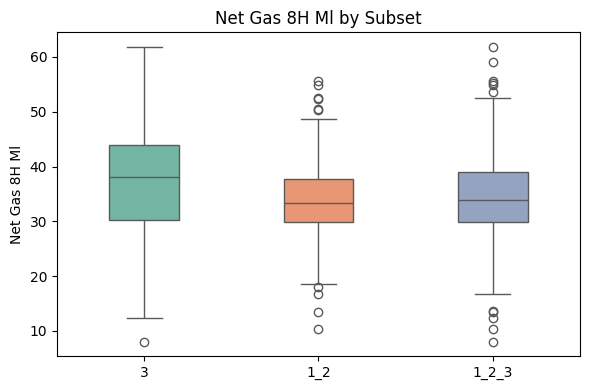

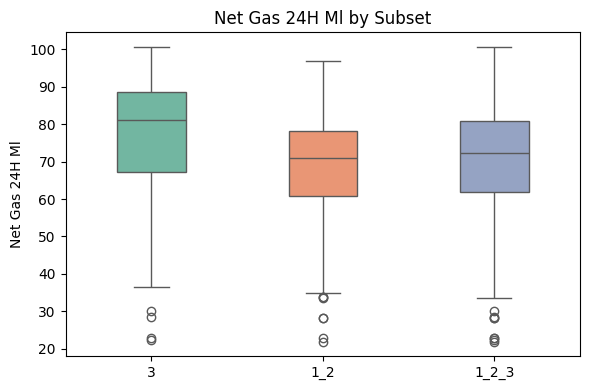

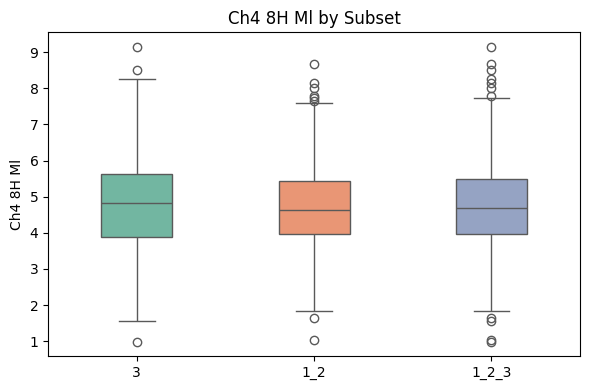

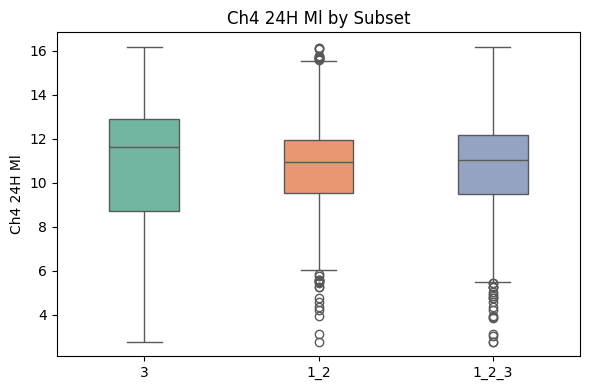

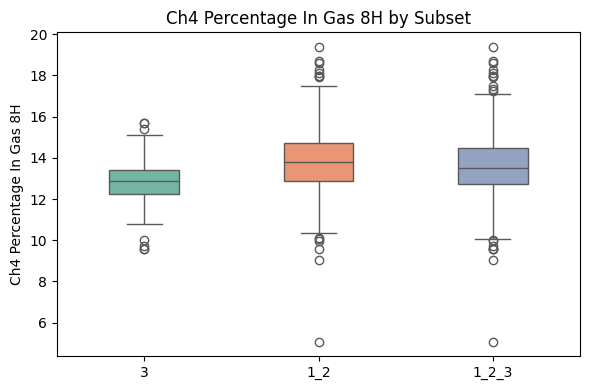

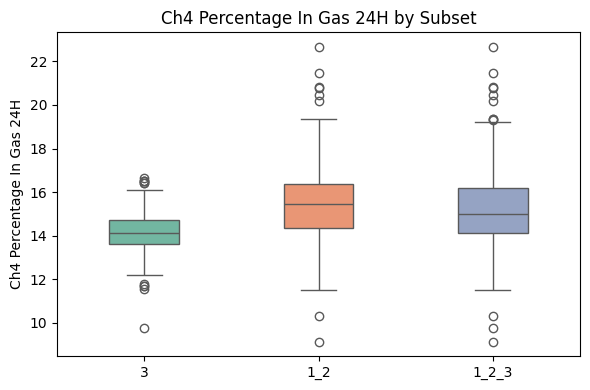

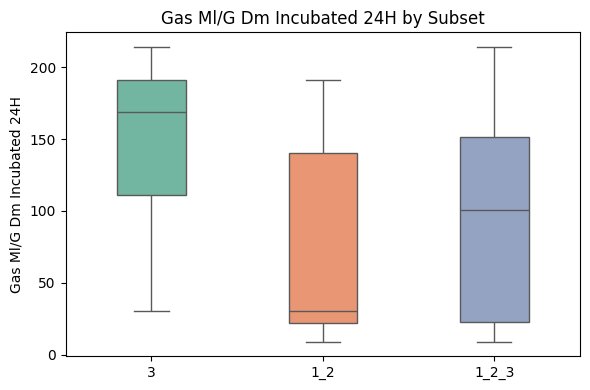

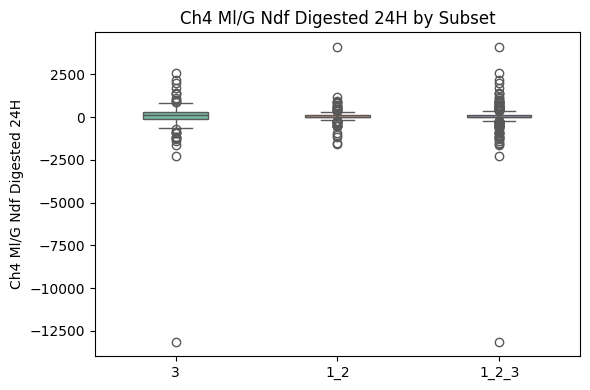

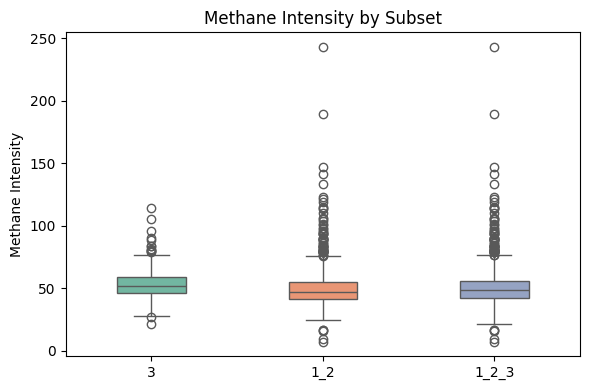

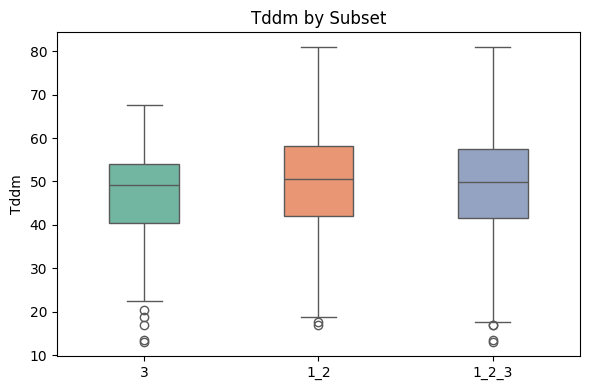

In [ ]:
# Create copies to avoid modifying original dataframes during concatenation
subset_3_temp = subset_3[numeric_columns].copy()
subset_12_temp = subset_12[numeric_columns].copy()
subset_123_temp = subset_123[numeric_columns].copy()

# Add a Center column to each dataframe
subset_3_temp['Subset'] = '3'
subset_12_temp['Subset'] = '1_2'
subset_123_temp['Subset'] = '1_2_3'

# Concatenate the dataframes
combined_gas_data = pd.concat([

    subset_3_temp,
    subset_12_temp,
    subset_123_temp,
], ignore_index=True)

# Generate box plots for each numeric variable, comparing across Centers
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Subset', y=col, data=combined_gas_data, palette='Set2', width=0.4)
    plt.title(f'{col.replace("_", " ").title()} by Subset')
    plt.ylabel(col.replace("_", " ").title())
    plt.xlabel('')
    #plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

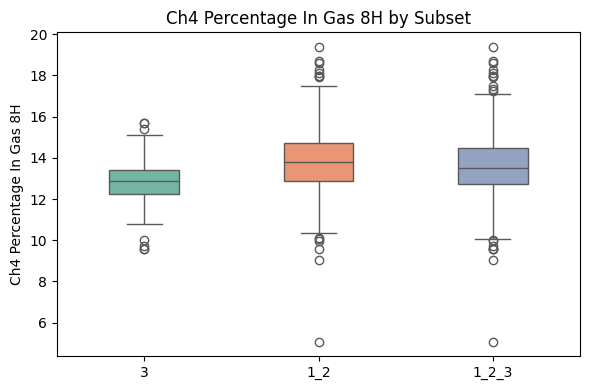

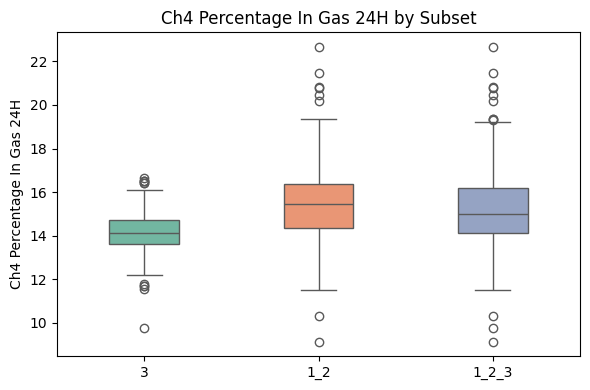

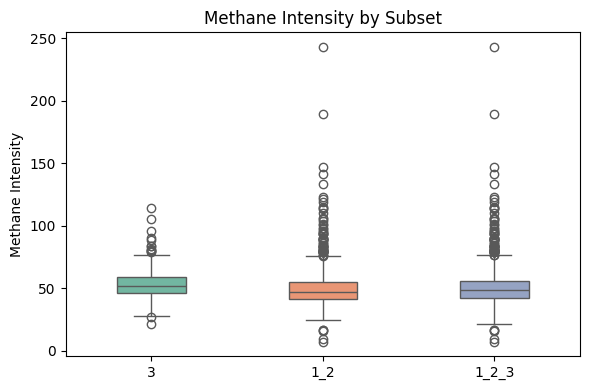

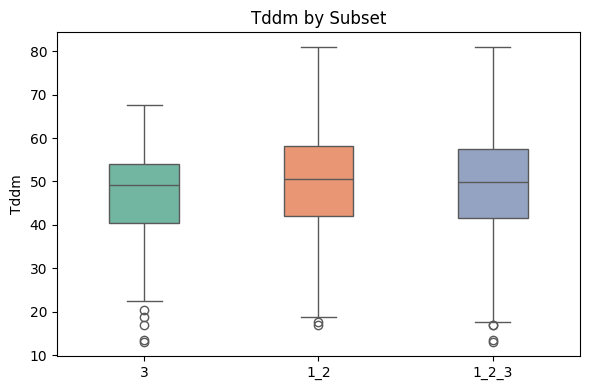

In [ ]:
# Define the numeric columns again for clarity
numeric_columns = ['ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h', 'methane_intensity', 'tddm']

# Generate box plots for each numeric variable, comparing across Centers
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Subset', y=col, data=combined_gas_data, palette='Set2', width=0.4)
    plt.title(f'{col.replace("_", " ").title()} by Subset')
    plt.ylabel(col.replace("_", " ").title())
    plt.xlabel('')
    #plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Individual Boxplots

In [ ]:
combined_gas_data.columns

Index(['net_gas_8h_ml', 'net_gas_24h_ml', 'ch4_8h_ml', 'ch4_24h_ml',
       'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h',
       'gas_ml/g_dm_incubated_24h', 'ch4_ml/g_NDF_digested_24h',
       'methane_intensity', 'tddm', 'Subset'],
      dtype='object')

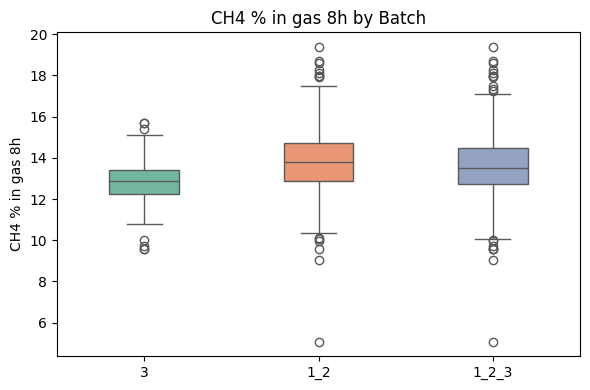

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Subset', y='ch4_percentage_in_gas_8h', data=combined_gas_data, palette='Set2', width=0.4)
plt.title("CH4 % in gas 8h by Batch")
plt.ylabel("CH4 % in gas 8h")
plt.xlabel('')
plt.tight_layout()
plt.show()

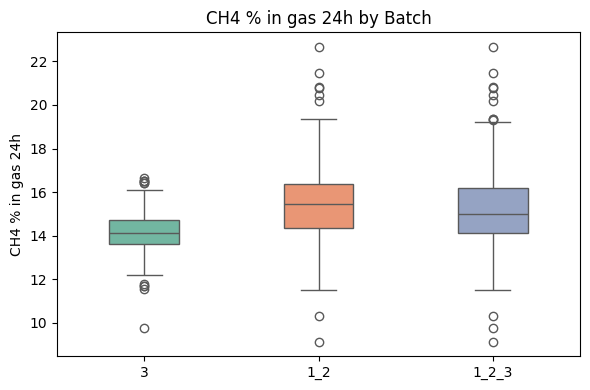

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Subset', y='ch4_percentage_in_gas_24h', data=combined_gas_data, palette='Set2', width=0.4)
plt.title("CH4 % in gas 24h by Batch")
plt.ylabel("CH4 % in gas 24h")
plt.xlabel('')
plt.tight_layout()
plt.show()

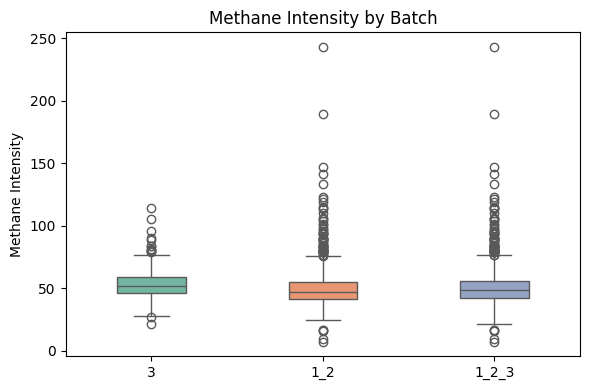

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Subset', y='methane_intensity', data=combined_gas_data, palette='Set2', width=0.4)
plt.title("Methane Intensity by Batch")
plt.ylabel("Methane Intensity")
plt.xlabel('')
plt.tight_layout()
plt.show()

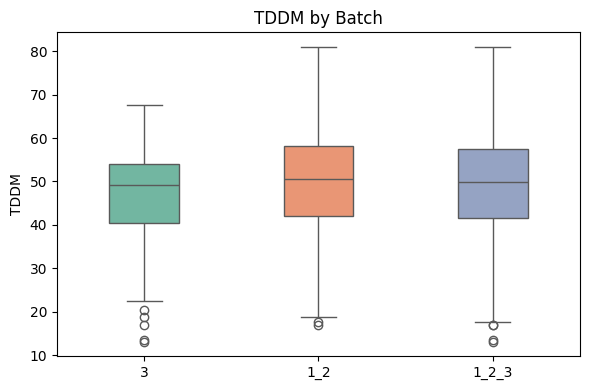

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Subset', y='tddm', data=combined_gas_data, palette='Set2', width=0.4)
plt.title("TDDM by Batch")
plt.ylabel("TDDM")
plt.xlabel('')
plt.tight_layout()
plt.show()

# Data for Dashboard

In [ ]:
subset_12_dashboard = subset_12.drop(columns=['subset','net_gas_8h_ml','net_gas_24h_ml','ch4_8h_ml','ch4_24h_ml','gas_ml/g_dm_incubated_24h','ch4_ml/g_NDF_digested_24h'])
subset_12_dashboard = subset_12_dashboard.sort_values(by='id')

In [ ]:
subset_12_dashboard

,id_lab,id,tax_name,functional_group,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
104,F24-3469,ABC-10647,Stylosanthes scabra,Herbaceous,15.90,18.79,48.31,67.34
282,F24-3636,ABC-11162,Stylosanthes scabra,Herbaceous,12.44,14.90,59.15,52.92
105,F24-3470,ABC-11194,Stylosanthes hamata,Herbaceous,15.17,18.03,46.12,59.25
427,F25-0989,ABC-11833,Stylosanthes guianensis,Herbaceous,11.63,13.19,63.62,30.51
408,F25-0970,ABC-11998,Stylosanthes guianensis,Herbaceous,11.18,11.95,44.53,41.12
...,...,...,...,...,...,...,...,...
11,F24-1047,nan,Albizzia saman,Tree,12.24,14.19,7.37,80.97
12,F24-1070,nan,Gliricidia sepium,Tree,10.34,14.07,16.79,76.64
13,F24-1075,nan,Leucaena diversifolia,Tree,9.58,13.74,9.44,78.04
14,F24-1084,nan,Brachiaria decumbens,Grass,9.02,10.31,16.24,72.50


In [ ]:
subset_3_dashboard = subset_3.drop(columns=['subset','net_gas_8h_ml','net_gas_24h_ml','ch4_8h_ml','ch4_24h_ml','gas_ml/g_dm_incubated_24h','ch4_ml/g_NDF_digested_24h'])
subset_3_dashboard = subset_3_dashboard.sort_values(by='id')
subset_3_dashboard

,id_lab,id,tax_name,functional_group,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
606,F25-2137,CIAT_606_Basilisk_Opt,Brachiaria interespecifico,grasses,13.00,13.80,46.81,53.35
607,F25-2138,CIAT_6294_Marandu_Opt,Brachiaria interespecifico,grasses,13.10,13.70,58.91,46.34
615,F24-3549,ABC-10440,Stylosanthes humilis,Herbaceous,12.24,13.73,45.94,54.20
616,F24-3550,ABC-10613,Stylosanthes scabra,Herbaceous,12.26,13.87,63.05,39.50
617,F24-3551,ABC-10627,Stylosanthes scabra,Herbaceous,12.49,13.61,46.84,47.71
...,...,...,...,...,...,...,...,...
565,F25-2131,Muestra # 02,Cynodon nlemfuensis,Grasses,13.92,14.71,114.30,20.33
611,F25-2566,Paja Sabana Madura,0,grasses,12.56,13.60,65.01,13.13
613,F25-2568,Sabana Quemada,0,grasses,12.20,13.46,52.52,13.51
654,F25-2639,nan,Gliricidia sepium,Arbustiva,12.94,13.95,45.45,59.71


In [ ]:
# Define the mapping for functional groups
functional_group_mapping = {
    'Grasses': 'Grass',
    'grasses': 'Grass',
    'Shrub': 'Shrub_Trees',
    'Tree': 'Shrub_Trees',
    'Arbustiva ': 'Shrub_Trees', # # From subset_3_dashboard, This one has a space after Arbustiva
    'Herbáceas': 'Herbaceous_legumes', # From subset_3_dashboard
    'Herbáceas ': 'Herbaceous_legumes', # From subset_3_dashboard, This one has a space after Herbáceas
    'Herbaceous': 'Herbaceous_legumes',
    'Climber': 'Herbaceous_legumes',
    'Legume': 'Herbaceous_legumes'
}

# Apply the mapping to subset_12_dashboard
subset_12_dashboard['functional_group'] = subset_12_dashboard['functional_group'].replace(functional_group_mapping)

# Apply the mapping to subset_3_dashboard
subset_3_dashboard['functional_group'] = subset_3_dashboard['functional_group'].replace(functional_group_mapping)

print('Updated functional group counts for subset_12_dashboard:')
display(subset_12_dashboard.functional_group.value_counts())

print('\nUpdated functional group counts for subset_3_dashboard:')
display(subset_3_dashboard.functional_group.value_counts())

Updated functional group counts for subset_12_dashboard:


,count
functional_group,
Herbaceous_legumes,232
Grass,171
Shrub_Trees,55
Forage,2
Browse,2
Concentrate,1
Hohenheimer Heustandard,1
0.00,0
BLANK 8H,0



Updated functional group counts for subset_3_dashboard:


,count
functional_group,
Herbaceous_legumes,94
Shrub_Trees,20
Grass,20
Dieta 2_Exp1,1
Dieta 1_Exp1,1
BLANK 8H,0
0.00,0
BLANK 24 H,0
Browse,0


In [ ]:
subset_12_dashboard.tail(20)

,id_lab,id,tax_name,functional_group,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
430,F25-2078,CIAT-PM21_6106,Megathyrsus maximus,Grass,14.51,16.02,40.45,58.82
436,F25-2084,CIAT-PM21_6598,Megathyrsus maximus,Grass,13.47,15.17,46.34,50.76
442,F25-2090,CIAT-PM21_6629,Megathyrsus maximus,Grass,13.68,15.16,47.95,44.82
440,F25-2088,CIAT-PM21_6640,Megathyrsus maximus,Grass,13.70,15.53,44.24,49.86
443,F25-2091,CIAT-PM21_6641,Megathyrsus maximus,Grass,14.36,15.81,48.44,51.47
437,F25-2085,CIAT-PM21_6647,Megathyrsus maximus,Grass,14.16,15.47,48.25,50.51
531,F25-0017,Hohenheimer Heustandard,Hohenheimer Heustandard,Concentrate,15.10,16.40,79.14,49.76
285,F25-0017,Hohenheimer Heustandard,Hohenheimer Heustandard,Forage,15.10,16.40,79.14,49.76
159,F25-0017,Hohenheimer Heustandard,Hohenheimer Heustandard,Hohenheimer Heustandard,15.10,16.40,79.14,49.76
136,F25-0017,Hohenheimer Heustandard,Hohenheimer Heustandard,Herbaceous_legumes,15.10,16.40,79.14,49.76


In [ ]:
subset_12_dashboard_filtered = subset_12_dashboard[:-14]
subset_12_dashboard_filtered.tail(10)

,id_lab,id,tax_name,functional_group,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
447,F25-2095,CIAT-PM21_3662,Megathyrsus maximus,Grass,13.86,15.31,64.31,44.73
448,F25-2096,CIAT-PM21_4448,Megathyrsus maximus,Grass,13.82,15.19,76.96,39.76
451,F25-2099,CIAT-PM21_4852,Megathyrsus maximus,Grass,13.86,15.24,106.21,33.03
446,F25-2094,CIAT-PM21_4926,Megathyrsus maximus,Grass,14.36,15.74,73.16,34.14
430,F25-2078,CIAT-PM21_6106,Megathyrsus maximus,Grass,14.51,16.02,40.45,58.82
436,F25-2084,CIAT-PM21_6598,Megathyrsus maximus,Grass,13.47,15.17,46.34,50.76
442,F25-2090,CIAT-PM21_6629,Megathyrsus maximus,Grass,13.68,15.16,47.95,44.82
440,F25-2088,CIAT-PM21_6640,Megathyrsus maximus,Grass,13.70,15.53,44.24,49.86
443,F25-2091,CIAT-PM21_6641,Megathyrsus maximus,Grass,14.36,15.81,48.44,51.47
437,F25-2085,CIAT-PM21_6647,Megathyrsus maximus,Grass,14.16,15.47,48.25,50.51


In [ ]:
#subset_12_dashboard_filtered.to_csv('/content/drive/MyDrive/lmf/output/03_25_2026/ciat_subset_12_dashboard.csv', index=False)

In [ ]:
subset_3_dashboard

,id_lab,id,tax_name,functional_group,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
606,F25-2137,CIAT_606_Basilisk_Opt,Brachiaria interespecifico,Grass,13.00,13.80,46.81,53.35
607,F25-2138,CIAT_6294_Marandu_Opt,Brachiaria interespecifico,Grass,13.10,13.70,58.91,46.34
615,F24-3549,ABC-10440,Stylosanthes humilis,Herbaceous_legumes,12.24,13.73,45.94,54.20
616,F24-3550,ABC-10613,Stylosanthes scabra,Herbaceous_legumes,12.26,13.87,63.05,39.50
617,F24-3551,ABC-10627,Stylosanthes scabra,Herbaceous_legumes,12.49,13.61,46.84,47.71
...,...,...,...,...,...,...,...,...
565,F25-2131,Muestra # 02,Cynodon nlemfuensis,Grass,13.92,14.71,114.30,20.33
611,F25-2566,Paja Sabana Madura,0,Grass,12.56,13.60,65.01,13.13
613,F25-2568,Sabana Quemada,0,Grass,12.20,13.46,52.52,13.51
654,F25-2639,nan,Gliricidia sepium,Shrub_Trees,12.94,13.95,45.45,59.71


In [ ]:
subset_3_dashboard.tail(20)

,id_lab,id,tax_name,functional_group,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
567,F25-2171,CIAT-BH22_2531,Urochloa humidicola,Grass,12.70,14.10,105.66,36.25
564,F25-2105,CIAT-BR09_4467,Brachiaria interespecifico,Grass,12.38,13.79,68.51,40.78
563,F25-2101,CIAT-CIAT_16071,Megathyrsus maximus,Grass,13.51,15.57,90.05,32.01
562,F25-2096,CIAT-PM21_4448,Megathyrsus maximus,Grass,13.82,15.19,76.96,39.76
640,F25-2625,CIAT_36087_MulatoII_Exc,Urochloa interespecifico,Grass,13.21,14.35,50.69,56.24
608,F25-2139,CIAT_36087_MulatoII_Opt,Brachiaria interespecifico,Grass,12.77,13.60,46.25,52.77
641,F25-2626,CIAT_606_Basilisk_Exc,Urochloa interespecifico,Grass,13.50,14.53,52.09,57.88
609,F25-2140,CIAT_6133_Llanero _Opt,Brachiaria humidicola,Grass,13.67,14.00,54.66,45.88
639,F25-2624,CIAT_6294_Marandu_Exc,Urochloa interespecifico,Grass,13.81,14.97,53.90,57.28
605,F25-2136,CIAT_6962_Mombaza _Ex,Megathyrsus maximus,Grass,12.87,13.34,57.01,39.34


In [ ]:
subset_3_dashboard_filtered = subset_3_dashboard[:-9]
subset_3_dashboard_filtered.tail(10)

,id_lab,id,tax_name,functional_group,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
564,F25-2105,CIAT-BR09_4467,Brachiaria interespecifico,Grass,12.38,13.79,68.51,40.78
563,F25-2101,CIAT-CIAT_16071,Megathyrsus maximus,Grass,13.51,15.57,90.05,32.01
562,F25-2096,CIAT-PM21_4448,Megathyrsus maximus,Grass,13.82,15.19,76.96,39.76
640,F25-2625,CIAT_36087_MulatoII_Exc,Urochloa interespecifico,Grass,13.21,14.35,50.69,56.24
608,F25-2139,CIAT_36087_MulatoII_Opt,Brachiaria interespecifico,Grass,12.77,13.60,46.25,52.77
641,F25-2626,CIAT_606_Basilisk_Exc,Urochloa interespecifico,Grass,13.50,14.53,52.09,57.88
609,F25-2140,CIAT_6133_Llanero _Opt,Brachiaria humidicola,Grass,13.67,14.00,54.66,45.88
639,F25-2624,CIAT_6294_Marandu_Exc,Urochloa interespecifico,Grass,13.81,14.97,53.90,57.28
605,F25-2136,CIAT_6962_Mombaza _Ex,Megathyrsus maximus,Grass,12.87,13.34,57.01,39.34
610,F25-2141,CIAT_6962_Mombaza _Opt,Megathyrsus maximus,Grass,12.74,14.16,54.15,44.76


In [ ]:
#subset_3_dashboard_filtered.to_csv('/content/drive/MyDrive/lmf/output/03_25_2026/ciat_subset_3_dashboard.csv', index=False)

# Subsets stats

In [ ]:
subset_12_dashboard_filtered_stats = subset_12_dashboard_filtered.describe().round(2)
subset_12_dashboard_filtered_stats

,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
count,450.00,450.00,450.00,450.00
mean,13.93,15.60,52.59,49.35
std,1.43,1.60,21.18,11.75
min,5.08,9.14,24.79,16.98
25%,12.93,14.40,41.39,41.65
50%,13.81,15.47,47.34,50.59
75%,14.70,16.38,54.81,58.02
max,19.38,22.66,243.09,75.03


In [ ]:
#subset_12_dashboard_filtered_stats.to_csv('/content/drive/MyDrive/lmf/output/03_25_2026/ciat_subset_12_dashboard_filtered_stats.csv')

In [ ]:
subset_3_dashboard_filtered_stats = subset_3_dashboard_filtered.describe().round(2)
subset_3_dashboard_filtered_stats

,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
count,129.00,129.00,129.00,129.00
mean,12.85,14.16,53.60,47.34
std,1.08,1.13,12.79,10.23
min,9.57,9.77,21.60,16.98
25%,12.24,13.60,46.32,41.30
50%,12.86,14.14,51.55,49.49
75%,13.38,14.66,57.80,54.20
max,15.67,16.66,105.66,67.60


In [ ]:
#subset_3_dashboard_filtered_stats.to_csv('/content/drive/MyDrive/lmf/output/03_25_2026/ciat_subset_3_dashboard_filtered_stats.csv')

# Comparative plots

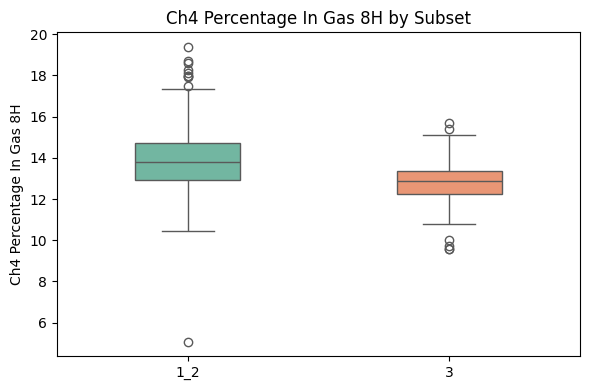

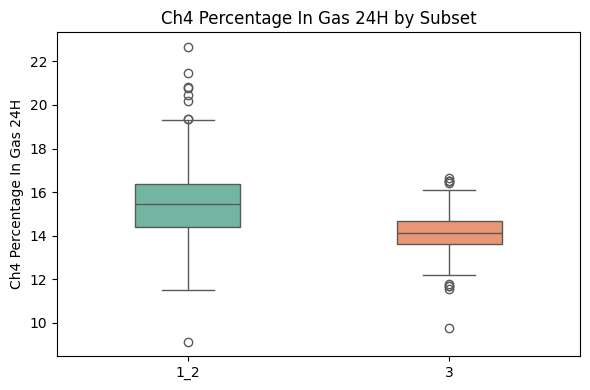

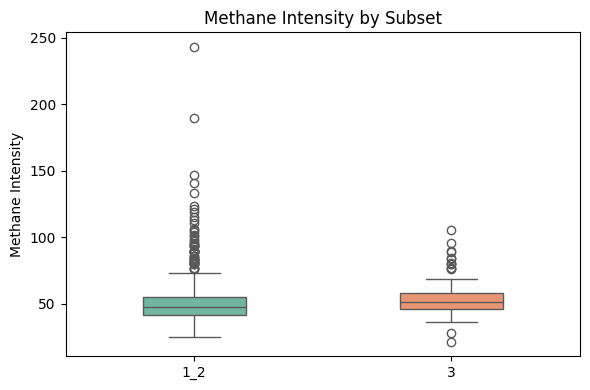

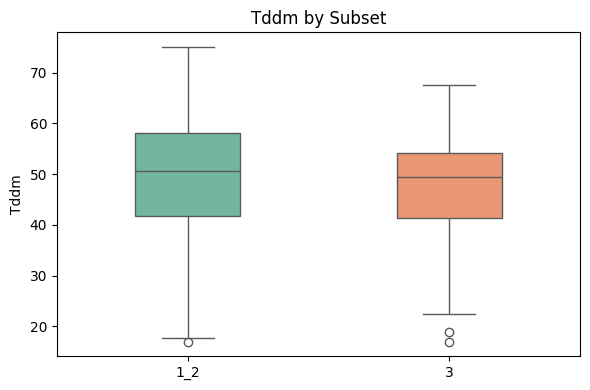

In [ ]:
# Create copies to avoid modifying original dataframes during concatenation
subset_12_temp = subset_12_dashboard_filtered[numeric_columns].copy()
subset_3_temp = subset_3_dashboard_filtered[numeric_columns].copy()

# Add a Center column to each dataframe
subset_12_temp['Subset'] = '1_2'
subset_3_temp['Subset'] = '3'

# Concatenate the dataframes
combined_gas_data = pd.concat([
    subset_12_temp,
    subset_3_temp,
], ignore_index=True)

import os

# Define the directory to save the plots
save_dir = '/content/drive/MyDrive/lmf/output/03_25_2026/plots/'
os.makedirs(save_dir, exist_ok=True)

# Generate box plots for each numeric variable, comparing across Centers
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Subset', y=col, data=combined_gas_data, palette='Set2', width=0.4)
    plt.title(f'{col.replace("_", " ").title()} by Subset')
    plt.ylabel(col.replace("_", " ").title())
    plt.xlabel('')
    #plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save the plot
    filename = f"{save_dir}{col}_boxplot.png"
    plt.savefig(filename)
    plt.show()